In [1]:
import math, os, time, shutil, torch, matplotlib as mpl, numpy as np
from torch import tensor
from fastcore.test import test_close
torch.manual_seed(42)


mpl.rcParams['image.cmap'] = 'gray'
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)


In [2]:
from fastai.vision.all import *

In [3]:
dataset = Path(r'C:\Users\USER\Practical Deep learning\Datasets\Digits_classifier_datasets')
dataset.ls()

[Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/test_set'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set')]

In [4]:
train_set = dataset/'train_set'
valid_set = dataset/'test_set'

In [5]:
train_set.ls()

[Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/0'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/1'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/2'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/3'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/4'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/5'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/6'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/7'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/8'), Path('C:/Users/USER/Practical Deep learning/Datasets/Digits_classifier_datasets/train_set/9')]

In [6]:
zero = (train_set/'0').ls().sorted()
one = (train_set/'1').ls().sorted()
two = (train_set/'2').ls().sorted()
three = (train_set/'3').ls().sorted()
four = (train_set/'4').ls().sorted()
five = (train_set/'5').ls().sorted()
six = (train_set/'6').ls().sorted()
seven = (train_set/'7').ls().sorted()
eight = (train_set/'8').ls().sorted()
nine = (train_set/'9').ls().sorted()

In [7]:
valid_zero = (valid_set/'0').ls().sorted()
valid_one = (valid_set/'1').ls().sorted()
valid_two = (valid_set/'2').ls().sorted()
valid_three = (valid_set/'3').ls().sorted()
valid_four = (valid_set/'4').ls().sorted()
valid_five = (valid_set/'5').ls().sorted()
valid_six = (valid_set/'6').ls().sorted()
valid_seven = (valid_set/'7').ls().sorted()
valid_eight = (valid_set/'8').ls().sorted()
valid_nine = (valid_set/'9').ls().sorted()

In [8]:
def stack(digit):
    tensors = [tensor(Image.open(o)) for o in digit]
    stack = torch.stack(tensors).float()/255
    return stack

In [9]:
zero_stack = stack(zero)
one_stack = stack(one)
two_stack = stack(two)
three_stack = stack(three)
four_stack = stack(four)
five_stack = stack(five)
six_stack = stack(six)
seven_stack = stack(seven)
eight_stack = stack(eight)
nine_stack = stack(nine)

In [10]:
valid_zero_stack = stack(valid_zero)
valid_one_stack = stack(valid_one)
valid_two_stack = stack(valid_two)
valid_three_stack = stack(valid_three)
valid_four_stack = stack(valid_four)
valid_five_stack = stack(valid_five)
valid_six_stack = stack(valid_six)
valid_seven_stack = stack(valid_seven)
valid_eight_stack = stack(valid_eight)
valid_nine_stack = stack(valid_nine)

In [11]:
x_train = torch.cat([zero_stack, one_stack, two_stack, three_stack, four_stack, five_stack, six_stack, seven_stack, eight_stack, nine_stack]).view(-1, 28*28)
y_train = tensor([0]*len(zero_stack) + [1]*len(one_stack) + [2]*len(two_stack) + [3]*len(three_stack) + [4]*len(four_stack) + [5]*len(five_stack) + [6]*len(six_stack) + [7]*len(seven_stack) + [8]*len(eight_stack) + [9]*len(nine_stack))

In [12]:
x_valid = torch.cat([valid_zero_stack, valid_one_stack, valid_two_stack, valid_three_stack, valid_four_stack, valid_five_stack, valid_six_stack, valid_seven_stack, valid_eight_stack, valid_nine_stack]).view(-1, 28*28)
y_valid = tensor([0]*len(valid_zero_stack) + [1]*len(valid_one_stack) + [2]*len(valid_two_stack) + [3]*len(valid_three_stack) + [4]*len(valid_four_stack) + [5]*len(valid_five_stack) + [6]*len(valid_six_stack) + [7]*len(valid_seven_stack) + [8]*len(valid_eight_stack) + [9]*len(valid_nine_stack))

In [13]:
x_train[200:300]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [14]:
n, m = x_train.shape
c = y_train.max()+1
nh = 50

In [15]:
class Model(Module):
    def __init__(self, n_in, nh, n_out):
        super().__init__()
        self.layers = [nn.Linear(n_in, nh), nn.ReLU(), nn.Linear(nh, n_out)]

    def __call__(self, x):
        for l in self.layers: x = l(x)
        return x

In [16]:
model = Model(m, nh, 10)
pred = model(x_train)
pred.shape

torch.Size([1000, 10])

In [17]:
def log_softmax(x): return (x.exp()/(x.exp().sum(-1, keepdim=True))).log()

In [18]:
log_softmax(pred)

tensor([[-2.37, -2.44, -2.44,  ..., -2.27, -2.26, -2.15],
        [-2.32, -2.47, -2.46,  ..., -2.28, -2.30, -2.15],
        [-2.31, -2.47, -2.38,  ..., -2.33, -2.30, -2.14],
        ...,
        [-2.37, -2.42, -2.30,  ..., -2.30, -2.26, -2.18],
        [-2.26, -2.55, -2.32,  ..., -2.33, -2.32, -2.11],
        [-2.36, -2.52, -2.30,  ..., -2.30, -2.28, -2.20]], grad_fn=<LogBackward0>)

In [19]:
def log_softmax(x): return x - x.exp().sum(-1, keepdim=True).log()

In [20]:
log_softmax(pred)

tensor([[-2.37, -2.44, -2.44,  ..., -2.27, -2.26, -2.15],
        [-2.32, -2.47, -2.46,  ..., -2.28, -2.30, -2.15],
        [-2.31, -2.47, -2.38,  ..., -2.33, -2.30, -2.14],
        ...,
        [-2.37, -2.42, -2.30,  ..., -2.30, -2.26, -2.18],
        [-2.26, -2.55, -2.32,  ..., -2.33, -2.32, -2.11],
        [-2.36, -2.52, -2.30,  ..., -2.30, -2.28, -2.20]], grad_fn=<SubBackward0>)

In [21]:
def logsumexp(x):
    m = x.max(-1)[0]
    return m + (x-m[:, None]).exp().sum(-1).log()

In [22]:
def log_softmax(x): return x - x.logsumexp(-1, keepdim=True)

In [23]:
test_close(logsumexp(pred), pred.logsumexp(-1))
sm_pred = log_softmax(pred)
sm_pred

tensor([[-2.37, -2.44, -2.44,  ..., -2.27, -2.26, -2.15],
        [-2.32, -2.47, -2.46,  ..., -2.28, -2.30, -2.15],
        [-2.31, -2.47, -2.38,  ..., -2.33, -2.30, -2.14],
        ...,
        [-2.37, -2.42, -2.30,  ..., -2.30, -2.26, -2.18],
        [-2.26, -2.55, -2.32,  ..., -2.33, -2.32, -2.11],
        [-2.36, -2.52, -2.30,  ..., -2.30, -2.28, -2.20]], grad_fn=<SubBackward0>)

In [24]:
y_train[:3]

tensor([0, 0, 0])

In [25]:
sm_pred[0, 5], sm_pred[1, 0], sm_pred[2, 4]

(tensor(-2.16, grad_fn=<SelectBackward0>),
 tensor(-2.32, grad_fn=<SelectBackward0>),
 tensor(-2.34, grad_fn=<SelectBackward0>))

In [26]:
sm_pred[[0, 1, 2], y_train[:3]]

tensor([-2.37, -2.32, -2.31], grad_fn=<IndexBackward0>)

In [27]:
def nll(input, target): return -input[range(target.shape[0]), target].mean()

In [28]:
loss = nll(sm_pred, y_train)
loss

tensor(2.30, grad_fn=<NegBackward0>)

In [29]:
test_close(F.nll_loss(F.log_softmax(pred, -1), y_train), loss, 1e-3)

In [30]:
test_close(F.cross_entropy(sm_pred, y_train), loss, 1e-3)

In [31]:
loss_func = F.cross_entropy

In [32]:
bs = 50
xb = x_train[0:bs]
preds = model(xb)
preds[0], preds.shape

(tensor([-0.07, -0.14, -0.14, -0.03,  0.00,  0.14, -0.04,  0.03,  0.04,  0.15], grad_fn=<SelectBackward0>),
 torch.Size([50, 10]))

In [33]:
yb = y_train[0:bs]
yb

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])

In [34]:
loss_func(preds, yb)

tensor(2.34, grad_fn=<NllLossBackward0>)

In [35]:
preds.argmax(dim=1)

tensor([9, 5, 9, 8, 9, 6, 9, 9, 5, 9, 3, 9, 5, 9, 9, 8, 9, 9, 8, 3, 9, 8, 8, 9, 9, 9, 9, 9, 9, 9, 8, 5, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 8, 9, 9])

In [36]:
def accuracy(out, yb): return (out.argmax(dim=1)==yb).float().mean()

In [37]:
accuracy(preds, yb)

tensor(0.)

In [38]:
lr = 0.5
epochs = 3

In [39]:
def report(loss, preds, yb): print(f'{loss:.2f}, {accuracy(preds, yb):.2f}')

In [40]:
xb, yb = x_train[:bs], y_train[:bs]
preds = model(xb)
report(loss_func(preds, yb), preds, yb)

2.34, 0.00


In [41]:
for epoch in range(epochs):
    for i in range(0, n, bs):
        s = slice(i, min(n, i+bs))
        xb, yb = x_train[s], y_train[s]
        preds = model(xb)
        loss = loss_func(preds, yb)
        loss.backward()
        with torch.no_grad():
            for l in model.layers:
                if hasattr(l, 'weight'):
                    l.weight -= l.weight.grad*lr
                    l.bias -= l.bias.grad*lr
                    l.weight.grad.zero_()
                    l.bias.grad.zero_()
    report(loss, preds, yb)                    

2.34, 0.00
2.23, 0.00
2.23, 0.00


In [42]:
m1 = nn.Module()
m1.foo = nn.Linear(3, 4)
m1

Module(
  (foo): Linear(in_features=3, out_features=4, bias=True)
)

In [43]:
list(m1.named_children())

[('foo', Linear(in_features=3, out_features=4, bias=True))]

In [44]:
m1.named_children()

<generator object Module.named_children at 0x0000020AE4EEEA40>

In [45]:
list(m1.parameters())

[Parameter containing:
 tensor([[ 0.57,  0.43, -0.30],
         [ 0.13, -0.32, -0.24],
         [ 0.51,  0.04,  0.22],
         [ 0.13, -0.17, -0.24]], requires_grad=True),
 Parameter containing:
 tensor([-0.01, -0.51, -0.39,  0.56], requires_grad=True)]

In [46]:
class MLP(nn.Module):
    def __init__(self, n_in, nh, n_out):
        super().__init__()
        self.l1 = nn.Linear(n_in, nh)
        self.l2 = nn.Linear(nh, n_out)
        self.relu = nn.ReLU()

    def forward(self, x):return self.l2(self.relu(self.l1(x)))

In [47]:
model = MLP(m, nh, 10)
model.l1

Linear(in_features=784, out_features=50, bias=True)

In [48]:
model

MLP(
  (l1): Linear(in_features=784, out_features=50, bias=True)
  (l2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
)

In [49]:
for name, l in model.named_children():print(f'{name}: {l}')

l1: Linear(in_features=784, out_features=50, bias=True)
l2: Linear(in_features=50, out_features=10, bias=True)
relu: ReLU()


In [50]:
for p in model.parameters(): print(p.shape)

torch.Size([50, 784])
torch.Size([50])
torch.Size([10, 50])
torch.Size([10])


In [51]:
def fit():
    for epoch in range(epochs):
        for i in range(0, n, bs):
            s = slice(i, min(n, i+bs))
            xb, yb = x_train[s], y_train[s]
            preds = model(xb)
            loss = loss_func(preds, yb)
            loss.backward()
            with torch.no_grad():
                for p in model.parameters(): p -=p.grad*lr
                model.zero_grad
        report(loss, preds, yb)

In [52]:
fit()

6.32, 0.00
4.38, 0.00
6.16, 0.00


In [53]:
class MyModule:
    def __init__(self, n_in, nh, n_out):
        self._modules = {}
        self.l1 = nn.Linear(n_in, nh)
        self.l2 = nn.Linear(nh, n_out)

    def __setattr__(self, k, v):
        if not k.startswith('_'): self._modules[k] = v
        super().__setattr__(k, v)

    def __repr__(self): return f'{self._modules}'

    def parameters(self):
        for l in self._modules.values(): yield from l.parameters()

In [54]:
mdl = MyModule(m, nh, 10)
mdl

{'l1': Linear(in_features=784, out_features=50, bias=True), 'l2': Linear(in_features=50, out_features=10, bias=True)}

In [55]:
for p in mdl.parameters(): print(p.shape)

torch.Size([50, 784])
torch.Size([50])
torch.Size([10, 50])
torch.Size([10])


In [56]:
from functools import reduce

In [57]:
layers = [nn.Linear(m, nh),nn.ReLU(),  nn.Linear(nh, 10)]

In [58]:
class Model(Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = layers
        for i, l in enumerate(self.layers): self.add_module(f'layer_{i}', l)

    def forward(self, x):
        return reduce(lambda val, layer: layer(val), self.layers, x)

In [59]:
model = Model(layers)
model

Model(
  (layer_0): Linear(in_features=784, out_features=50, bias=True)
  (layer_1): ReLU()
  (layer_2): Linear(in_features=50, out_features=10, bias=True)
)

In [60]:
model(xb).shape

torch.Size([50, 10])

In [61]:
class SequentialModel(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for l in layers: x = l(x)
        return x

In [62]:
model = SequentialModel(layers)
model

SequentialModel(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)

In [63]:
fit()

5.94, 0.00
7.80, 0.00
8.63, 0.00


In [64]:
model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, 10))

In [65]:
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

6.31, 0.00
6.42, 0.00
4.87, 0.00


(tensor(3.91, grad_fn=<NllLossBackward0>), tensor(0.))

In [66]:
model

Sequential(
  (0): Linear(in_features=784, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=10, bias=True)
)

In [67]:
class Optimizer():
    def __init__(self, params, lr=0.5): self.params, self.lr = list(params), lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                p -= p.grad * self.lr

    def zero_grad(self):
        for p in self.params:p.grad.data.zero_()

In [68]:
model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, 10))

In [69]:
opt = Optimizer(model.parameters())

In [70]:
for epoch in range(epochs):
    for i in range(0, n, bs):
        s = slice(i, min(n , i+bs))
        xb, yb = x_train[s], y_train[s]
        preds = model(xb)
        loss = loss_func(preds, yb)
        loss.backward()
        opt.step()
        opt.zero_grad()
    report(loss, preds, yb)

2.41, 0.00
2.30, 0.00
2.27, 0.00


In [71]:
from torch import optim

In [72]:
def get_model():
    model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, 10))
    return model, optim.SGD(model.parameters(), lr=lr)

In [73]:
model, opt = get_model()
loss_func(model(xb), yb)

tensor(2.26, grad_fn=<NllLossBackward0>)

In [74]:
for epoch in range(epochs):
    for i in range(0, n, bs):
        s = slice(i, min(n, i+bs))
        xb, yb = x_train[s], y_train[s]
        preds = model(xb)
        loss = loss_func(preds, yb)
        loss.backward
        opt.step
        opt.zero_grad()
    report(loss, preds, yb)

2.26, 0.04
2.26, 0.04
2.26, 0.04


In [75]:
class Dataset():
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

In [76]:
train_ds, valid_ds = Dataset(x_train, y_train), Dataset(x_valid, y_valid)
assert len(train_ds) == len(x_train)
assert len(valid_ds) == len(x_valid)

In [77]:
xb, yb = train_ds[0:5]
assert xb.shape == (5,28*28)
assert yb.shape == (5,)
xb, yb

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0, 0, 0, 0, 0]))

In [78]:
model, opt = get_model()

In [79]:
for epoch in range(epochs):
    for i in range(0, n, bs):
        xb, yb = train_ds[i: min(n, i+bs)] 
        preds = model(xb)
        loss = loss_func(preds, yb)
        loss.backward()
        opt.step()
        opt.zero_grad()
    report(loss, preds, yb)
        

2.29, 0.00
2.23, 0.00
2.21, 0.00


In [80]:
class DataLoader():
    def __init__(self, ds, bs): self.ds, self.bs = ds, bs
    def __iter__(self): 
        for i in range(0, len(self.ds), self.bs): yield self.ds[i:i+self.bs]

In [81]:
train_dl = DataLoader(train_ds, bs)
valid_dl = DataLoader(valid_ds, bs)

In [82]:
xb, yb = next(iter(valid_dl))
xb.shape

torch.Size([50, 784])

In [83]:
yb

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0])

tensor(0)

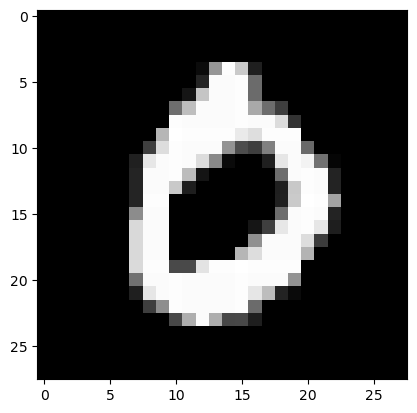

In [84]:
plt.imshow(xb[0].view(28, 28))
yb[0]

In [85]:
model, opt = get_model()

In [86]:
def fit():
    for epoch in range(epochs):
        for xb, yb in train_dl:
            preds = model(xb)
            loss = loss_func(preds, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        report(loss, preds, yb)

In [87]:
fit()
loss_func(model(xb), yb), accuracy(model(xb), yb)

2.17, 0.26
2.48, 0.00
2.31, 0.00


(tensor(2.75, grad_fn=<NllLossBackward0>), tensor(0.))

In [88]:
import random

In [89]:
class Sampler():
    def __init__(self, ds, shuffle=False): self.n, self.shuffle = len(ds), shuffle
    def __iter__(self): 
        res = list(range(self.n))
        if self.shuffle : random.shuffle(res)
        return iter(res)

In [90]:
from itertools import islice

In [91]:
ss = Sampler(train_ds)

In [92]:
it = iter(ss)
for o in range(5): print(next(it))

0
1
2
3
4


In [93]:
list(islice(ss, 5))

[0, 1, 2, 3, 4]

In [94]:
ss = Sampler(train_ds, shuffle=True)
list(islice(ss, 5))

[753, 720, 108, 402, 39]

In [95]:
import fastcore.all as fc

In [96]:
class BatchSampler():
    def __init__(self, sampler, bs, drop_last=False): fc.store_attr()
    def __iter__(self): yield from fc.chunked(iter(self.sampler), self.bs, drop_last = self.drop_last)

In [97]:
batchs = BatchSampler(ss, 4)
list(islice(batchs, 5))

[[470, 477, 138, 946],
 [448, 192, 195, 168],
 [953, 118, 103, 504],
 [899, 442, 912, 295],
 [144, 908, 120, 461]]

In [98]:
def collate(b):
    xs, ys = zip(*b)
    return torch.stack(xs), torch.stack(ys)

In [99]:
class DataLoader():
    def __init__(self, ds, batchs, collate_fn=collate): fc.store_attr()
    def __iter__(self): yield from (self.collate_fn(self.ds[i] for i in b) for b in self.batchs)

In [100]:
train_samp = BatchSampler(Sampler(train_ds, shuffle=True), bs)
valid_samp = BatchSampler(Sampler(valid_ds, shuffle=False), bs)

In [101]:
train_dl = DataLoader(train_ds, batchs=train_samp)
valid_dl = DataLoader(valid_ds, batchs=valid_samp)

tensor(0)

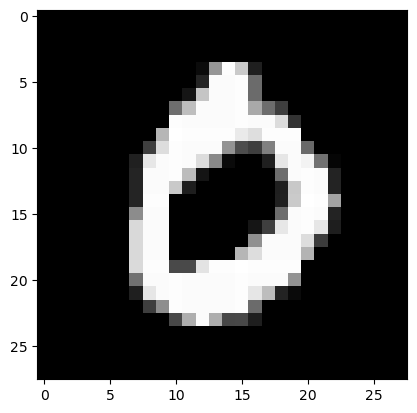

In [102]:
xb, yb = next(iter(valid_dl))
plt.imshow(xb[0].view(28, 28))
yb[0]

In [103]:
xb.shape, yb.shape

(torch.Size([50, 784]), torch.Size([50]))

In [104]:
model, opt = get_model()

In [105]:
fit()

1.25, 0.64
0.50, 0.84
0.67, 0.78


In [106]:
from multiprocessing.pool import Threadpool
from fastcore.basics import store_attr

ImportError: cannot import name 'Threadpool' from 'multiprocessing.pool' (C:\Users\USER\anaconda3\Lib\multiprocessing\pool.py)

In [108]:
train_ds[[3, 6, 8, 1]]

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0, 0, 0, 0]))

In [109]:
train_ds.__getitem__([[3, 6, 8, 1]])

C:\Users\USER\AppData\Local\Temp\ipykernel_11284\2019241488.py:4: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)
  def __getitem__(self, i): return self.x[i], self.y[i]


(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0, 0, 0, 0]))

In [110]:
for o in map(train_ds.__getitem__, ([3, 6], [8, 1])): print(o)

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([0, 0]))
(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([0, 0]))


In [111]:
class DataLoader():
    def __init__(self, ds, batchs, n_workers=0, collate_fn=collate): fc.store_attr()
    def __iter__(self):
        if self.n_workers=0:yield from ex.map(self.ds.__getitem__, iter(self.batchs))
        else:
            with mp.Pool(self.n_workers) as ex: yield from ex.map(self.ds.__getitem__, iter(self.batchs)) 

In [112]:
train_dl = DataLoader(train_ds, batchs=train_samp, n_workers=2)
it = iter(train_dl)

In [113]:
xb, yb = next(it)

In [114]:
#xb.shape, yb.shape

In [115]:
#from torch.utils.data import DataLoader, SequentialSampler, RandomSampler, BatchSampler

In [116]:
#train_samp = BatchSampler(RandomSampler(train_ds), bs, drop_last=False)
#valid_samp = BatchSampler(SequentialSampler(valid_ds), bs, drop_last=False)